In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


SEED = 42



## Data Exploration ##


In [6]:
DATA_PATH = "data/"

#loading data
sales = pd.read_csv(DATA_PATH+ "sales_train_validation.csv")
calendar = pd.read_csv(DATA_PATH + "calendar.csv")
prices = pd.read_csv(DATA_PATH + "sell_prices.csv")

sales = sales.sample(2000, random_state=42)


print(sales.shape, calendar.shape, prices.shape)

(2000, 1919) (1969, 14) (6841121, 4)


In [17]:
sales.iloc[:, 1:10].head()

,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4
2404,FOODS_3_180,FOODS_3,FOODS,CA_1,CA,0,0,0,0
7576,HOUSEHOLD_2_383,HOUSEHOLD_2,HOUSEHOLD,CA_3,CA,2,0,2,0
8731,FOODS_3_409,FOODS_3,FOODS,CA_3,CA,0,0,0,0
4756,FOODS_1_097,FOODS_1,FOODS,CA_2,CA,0,0,0,0
15509,HOBBIES_1_272,HOBBIES_1,HOBBIES,TX_2,TX,0,0,0,0


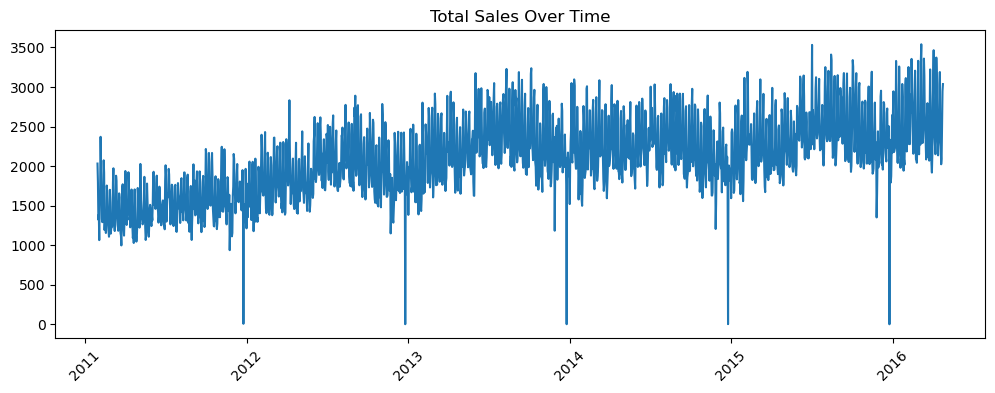

In [ ]:
daily_sales = sales.iloc[:, 6:].sum(axis=0)

daily_sales = daily_sales.reset_index()
daily_sales.columns = ['d', 'sales']

daily_sales = daily_sales.merge(calendar[['d', 'date']], on='d')
daily_sales['date'] = pd.to_datetime(daily_sales['date'])


plt.figure(figsize=(12,4))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title("Total Sales Over Time")
plt.xticks(rotation=45)
plt.show()

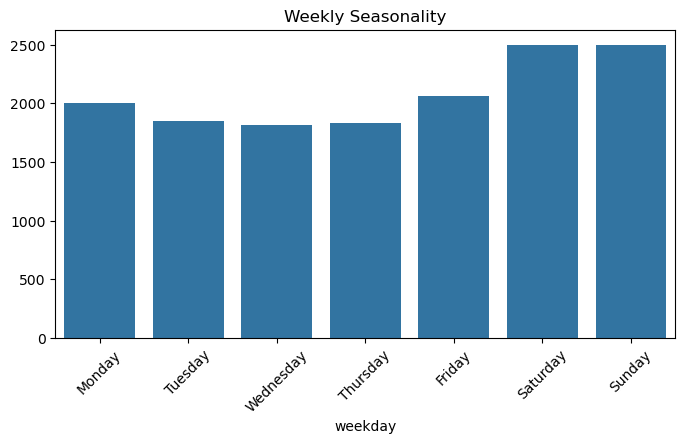

In [12]:
daily_sales['weekday'] = daily_sales['date'].dt.day_name()

weekly = daily_sales.groupby('weekday')['sales'].mean()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']


plt.figure(figsize=(8,4))
sns.barplot(x=weekly.loc[order].index, y=weekly.loc[order].values)
plt.xticks(rotation=45)
plt.title("Weekly Seasonality")
plt.show()